# 07 · Poder estadístico y conjunto de evaluación real ampliado

**Alcance:** maximizar el poder estadístico de la evaluación —sobre todo en el estrato de
entidad exacta— usando el log real, y dejar los resultados listos para la monografía. Todo
reproducible, con separación estricta entre versión interna y versión anonimizada para el paper.

## 1. Diagnóstico: ¿cuál es el cuello de botella de poder?

La v1 evaluaba con `n=17` en el estrato clave (entidad exacta) → los p-valores salían
marginales aunque el efecto fuera consistente. Un intento previo subió el `n` repitiendo el
mismo patrón de filtro con distintos nombres sintéticos; pero como el nombre sintético **no
aparece en ningún documento**, esas consultas son casi idénticas para el recuperador. Eso es
**pseudo-replicación**: infla el `n` sin añadir información independiente, y viola el supuesto
de la prueba de Wilcoxon. No sube el poder real.

**La palanca correcta** es usar los **patrones de firma reales distintos** (reporte × combo de
filtros) como unidad de muestreo. En el log hay **101 patrones distintos con columna de nombre
propio**, más que suficientes para un `n` honesto de 50–60 en entidad exacta sin repetición
artificial.

## 2. Núcleo de recuperación y estadística (inline)

In [1]:
import json, sys, time, math, re, unicodedata, subprocess
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from scipy import stats as sp
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.25})
RAIZ=Path.cwd();
if RAIZ.name=="notebooks": RAIZ=RAIZ.parent
EXP=RAIZ/"experimentos"
cfg=yaml.safe_load((EXP/"config.yaml").read_text(encoding="utf-8"))
ontologia=yaml.safe_load((EXP/cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))
cargar=lambda p:[json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
tiene_gold=lambda q: any(g>0 for g in q.values())
def _g(q,d): return float(q.get(d,0.0))
def dcg(r,q,k): return sum((2.0**_g(q,d)-1)/math.log2(i+1) for i,d in enumerate(r[:k],1) if _g(q,d)>0)
def ndcg(r,q,k):
    idl=sorted((g for g in q.values() if g>0),reverse=True); idcg=sum((2.0**g-1)/math.log2(i+1) for i,g in enumerate(idl[:k],1))
    return 0.0 if idcg==0 else dcg(r,q,k)/idcg
def recall(r,q,k):
    rel={d for d,g in q.items() if g>0}; return 0.0 if not rel else sum(1 for d in r[:k] if d in rel)/len(rel)
def mrr(r,q,k):
    for i,d in enumerate(r[:k],1):
        if _g(q,d)>0: return 1.0/i
    return 0.0
def prec(r,q,k): return 0.0 if k==0 else sum(1 for d in r[:k] if _g(q,d)>0)/k
_ST=set("el la los las un una unos unas de del a ante con en para por que y o u se su sus lo al es son como mas pero sin sobre entre cada ya cuando donde cual quien cuanto muy este esta estos".split())
def tok(t):
    t=unicodedata.normalize("NFKD",t.lower()); t="".join(ch for ch in t if not unicodedata.combining(ch))
    return [x for x in re.findall(r"[a-z0-9]+",t) if x not in _ST and len(x)>1]
class BM25:
    def __init__(s,k1=1.5,b=0.75): s.k1,s.b=k1,b
    def fit(s,ids,txt):
        s.ids=list(ids); s.tf=[Counter(tok(t)) for t in txt]; s.len=[sum(cc.values()) for cc in s.tf]
        s.avg=(sum(s.len)/len(s.len)) if s.len else 0.0; df=Counter()
        for cc in s.tf: df.update(cc.keys())
        n=len(s.tf); s.idf={t:math.log(1+(n-d+0.5)/(d+0.5)) for t,d in df.items()}; return s
    def buscar(s,q):
        qt=tok(q); sc=np.zeros(len(s.ids))
        for i,tf in enumerate(s.tf):
            a=0.0
            for t in qt:
                if t in tf:
                    f=tf[t]; a+=s.idf.get(t,0)*f*(s.k1+1)/(f+s.k1*(1-s.b+s.b*s.len[i]/(s.avg or 1)))
            sc[i]=a
        return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _l2(m):
    n=np.linalg.norm(m,axis=1,keepdims=True); n[n==0]=1.0; return m/n
class STEnc:
    def __init__(s,modelo):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel,"all_tied_weights_keys"): PreTrainedModel.all_tied_weights_keys={}
        from sentence_transformers import SentenceTransformer
        s.m=SentenceTransformer(modelo,trust_remote_code=True); s.nombre=modelo.split("/")[-1]; s.dim=s.m.get_sentence_embedding_dimension()
    def encode(s,txt): return _l2(s.m.encode(list(txt),convert_to_numpy=True,normalize_embeddings=False).astype(np.float32))
class Dense:
    def __init__(s,enc): s.enc=enc
    def fit(s,ids,txt): s.ids=list(ids); s.mat=s.enc.encode(txt); return s
    def buscar(s,q):
        qv=s.enc.encode([q])[0]; sc=s.mat@qv; return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _norm(x):
    x=unicodedata.normalize("NFKD",x.lower()); return "".join(ch for ch in x if not unicodedata.combining(ch))
def rrf(a,b,k=60):
    ra={d:i+1 for i,(d,_) in enumerate(a)}; rb={d:i+1 for i,(d,_) in enumerate(b)}
    ds=[d for d,_ in a]+[d for d,_ in b if d not in ra]; big=len(ds)+k+1
    fus={d:1/(k+ra.get(d,big))+1/(k+rb.get(d,big)) for d in ds}
    return sorted(ds,key=lambda d:(-fus[d],d)), fus
class Detector:
    def __init__(s,onto):
        s.t=[]
        for cl,cu in onto.get("clases",{}).items():
            for x in [cl,*cu.get("sinonimos",[])]: s.t.append((_norm(x),cl))
        s.p=re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases(s,q):
        cq=_norm(q); return {cl for t,cl in s.t if t and t in cq}
    def np_(s,q):
        tks=s.p.findall(q)
        if not tks: return False
        pr=q.strip().split()[:1]; cand=[t for t in tks if not (pr and t==pr[0])]
        return any(_norm(t) not in {tt for tt,_ in s.t} for t in cand)
CONFIGS={1:"Denso puro",2:"Denso + ontología",3:"Híbrido (sin ontología)",4:"Híbrido + ontología",5:"Híbrido + ontología + realce"}
NB_BM25="BM25 (referencia léxica)"
class Motor:
    def __init__(s,docs,enc,onto,k1,b,krrf,lam):
        s.ids=[d["id"] for d in docs]; s.k=krrf; s.lam=lam; s.det=Detector(onto)
        s.ent={d["id"]:set(d["metadatos_ontologia"].get("entidades_principales",[])) for d in docs}
        s.esnp={d["id"]:bool(d.get("nombre_propio_buscable",False)) for d in docs}
        de=[d["descripcion"] for d in docs]; on=[d["texto_indexable"] for d in docs]
        s.bd=BM25(k1,b).fit(s.ids,de); s.bo=BM25(k1,b).fit(s.ids,on); s.dd=Dense(enc).fit(s.ids,de); s.do=Dense(enc).fit(s.ids,on)
    def ind(s,q,d):
        if s.det.clases(q)&s.ent.get(d,set()): return 1
        if s.det.np_(q) and s.esnp.get(d): return 1
        return 0
    def rec(s,cfg_,q):
        if cfg_==0: return [d for d,_ in s.bd.buscar(q)]
        if cfg_==1: return [d for d,_ in s.dd.buscar(q)]
        if cfg_==2: return [d for d,_ in s.do.buscar(q)]
        if cfg_==3: return rrf(s.bd.buscar(q),s.dd.buscar(q),s.k)[0]
        if cfg_==4: return rrf(s.bo.buscar(q),s.do.buscar(q),s.k)[0]
        _,f=rrf(s.bo.buscar(q),s.do.buscar(q),s.k); fin={d:v*(1+s.lam*s.ind(q,d)) for d,v in f.items()}
        return sorted(fin,key=lambda d:(-fin[d],d))
def evaluar(docs,consultas,qrels):
    enc=STEnc(cfg["encoder"]["modelo_st"]); mot=Motor(docs,enc,ontologia,cfg["bm25"]["k1"],cfg["bm25"]["b"],cfg["fusion"]["k_rrf"],cfg["realce"]["lambda"])
    confs=[(0,NB_BM25)]+list(CONFIGS.items()); cg=[c for c in consultas if tiene_gold(qrels.get(c["id"],{}))]
    por={n:{} for _,n in confs}
    for num,n in confs:
        for c in consultas:
            r=mot.rec(num,c["texto"])
            if tiene_gold(qrels.get(c["id"],{})):
                por[n][c["id"]]={"ndcg@10":ndcg(r,qrels[c["id"]],10),"recall@100":recall(r,qrels[c["id"]],100),"mrr@10":mrr(r,qrels[c["id"]],10),"p@10":prec(r,qrels[c["id"]],10)}
    ests=sorted({c["estrato"] for c in cg}); idsg=[c["id"] for c in cg]; idse={e:[c["id"] for c in cg if c["estrato"]==e] for e in ests}
    def agg(n,ids,m):
        v=[por[n][i][m] for i in ids if i in por[n]]; return float(np.mean(v)) if v else float("nan")
    return confs,por,ests,idsg,idse,agg,cg
# estadística
def wilcoxon(a,b):
    a,b=np.array(a,float),np.array(b,float); d=a-b
    if np.allclose(d,0): return {"p":None,"delta":0.0,"n":len(a)}
    try: s,p=sp.wilcoxon(a,b,zero_method="wilcox"); return {"p":float(p),"delta":float(d.mean()),"n":len(a)}
    except ValueError as e: return {"p":None,"delta":float(d.mean()),"n":len(a),"nota":str(e)}
def cliff(a,b):
    a,b=np.array(a,float),np.array(b,float)
    if len(a)==0 or len(b)==0: return 0.0
    gt=sum(x>y for x in a for y in b); lt=sum(x<y for x in a for y in b); return (gt-lt)/(len(a)*len(b))
def mag(d):
    ad=abs(d); return "insignificante" if ad<0.147 else "pequeño" if ad<0.33 else "mediano" if ad<0.474 else "grande"
def boot(v,n=2000,alpha=0.05,seed=42):
    v=np.array(v,float)
    if len(v)==0: return (None,None,None)
    rng=np.random.default_rng(seed); m=np.array([rng.choice(v,len(v),replace=True).mean() for _ in range(n)])
    return v.mean(),np.percentile(m,100*alpha/2),np.percentile(m,100*(1-alpha/2))
print("Núcleo + estadística listos.")

Núcleo + estadística listos.


## 3. Construcción del conjunto ampliado (silver, con capa gold candidata)

**Descripción técnica.** Se ejecuta `construir_eval_real_ampliado.py`: agrega el log por patrón
distinto, mapea al corpus, estratifica con tope por reporte (para no llenar todo con promoción),
sintetiza el texto desde los filtros reales, y marca 50 consultas como candidatas a anotación
gold. Emite versión interna y versión paper (sin PII: los nombres son sintéticos del gazetteer).

In [2]:
print(subprocess.run([sys.executable,"construir_eval_real_ampliado.py"],cwd=EXP,capture_output=True,text=True).stdout)
cons = cargar(EXP/"datos/consultas_real_ampliado.jsonl")
qrels = {r["id"]:r["relevancia"] for r in cargar(EXP/"datos/qrels_real_ampliado.jsonl")}
docs_v1 = cargar(EXP/cfg["rutas"]["corpus"])
resumen = pd.DataFrame(cons).groupby("estrato").agg(n=("id","size"),
              gold=("capa",lambda s:(s=="gold_candidate").sum())).sort_values("n",ascending=False)
print("Conjunto ampliado:",len(cons),"consultas |",docs_v1.__len__(),"docs (corpus v1)")
resumen

{
  "n_total": 129,
  "patrones_disponibles": {
    "documento_largo": 225,
    "entidad_exacta": 102,
    "operacional": 294,
    "ambigua": 93
  },
  "por_estrato": {
    "entidad_exacta": 55,
    "operacional": 35,
    "documento_largo": 25,
    "ambigua": 14
  },
  "gold_candidate_por_estrato": {
    "entidad_exacta": 20,
    "operacional": 12,
    "documento_largo": 10,
    "ambigua": 8
  },
  "n_gold_total": 50,
  "ejemplos_entidad_exacta": [
    "promoción de deportistas de la institución Colegio San Marcos por categoría, por etapa, por fecha",
    "promoción de deportistas de la institución Club Deportivo El Faro por categoría, por etapa, por fecha",
    "grupo del deportista Julián Gómez por categoría, por etapa, por disciplina",
    "personal de apoyo de la institución Escuela Nueva Esperanza por categoría, por etapa, por fecha",
    "grupo del deportista Camilo Duarte por categoría, por etapa, por disciplina",
    "personal de apoyo de la institución Club Deportivo El Faro p

,n,gold
estrato,,
entidad_exacta,55,20
operacional,35,12
documento_largo,25,10
ambigua,14,8


In [3]:
# versión interna vs paper (idénticas: nombres ya sintéticos; se verifica ausencia de PII)
paper = cargar(EXP/"datos/consultas_real_ampliado_paper.jsonl")
pd.DataFrame([{"estrato":a["estrato"],"capa":a["capa"],"consulta (interna)":a["texto"],"consulta (paper)":b["texto"]}
              for a,b in zip(cons[:6],paper[:6])])

,estrato,capa,consulta (interna),consulta (paper)
0,entidad_exacta,silver,promoción de deportistas de la institución Col...,promoción de deportistas de la institución Col...
1,entidad_exacta,gold_candidate,promoción de deportistas de la institución Clu...,promoción de deportistas de la institución Clu...
2,entidad_exacta,gold_candidate,grupo del deportista Julián Gómez por categorí...,grupo del deportista Julián Gómez por categorí...
3,entidad_exacta,silver,personal de apoyo de la institución Escuela Nu...,personal de apoyo de la institución Escuela Nu...
4,entidad_exacta,silver,grupo del deportista Camilo Duarte por categor...,grupo del deportista Camilo Duarte por categor...
5,entidad_exacta,gold_candidate,personal de apoyo de la institución Club Depor...,personal de apoyo de la institución Club Depor...


## 4. Escenario A — corpus v1 (17 reportes): poder en entidad exacta

**Objetivo.** Comparar el poder estadístico ANTES (n=17) y AHORA (n≈55) en el estrato central.

In [4]:
confs,por,ests,idsg,idse,agg,cg = evaluar(docs_v1,cons,qrels)
orden=[n for _,n in confs]
tabla=pd.DataFrame({m:{n:agg(n,idsg,m) for n in orden} for m in ["ndcg@10","mrr@10","recall@100","p@10"]}).loc[orden]
print("Encoder: jina-embeddings-v3 | consultas con gold:",len(cg),"| n entidad_exacta:",len(idse.get("entidad_exacta",[])))
tabla.style.highlight_max(subset=["ndcg@10","mrr@10"],color="#c9f0c9").format("{:.3f}")

Encoder: jina-embeddings-v3 | consultas con gold: 129 | n entidad_exacta: 55


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.880,0.855,1.000,0.095
Denso puro,0.951,0.941,1.000,0.098
Denso + ontología,0.967,0.961,1.000,0.098
Híbrido (sin ontología),0.924,0.903,1.000,0.099
Híbrido + ontología,0.949,0.935,1.000,0.099
Híbrido + ontología + realce,0.938,0.920,1.000,0.099


In [5]:
# nDCG@10 por estrato
dfe=pd.DataFrame({e:{n:agg(n,idse[e],"ndcg@10") for n in orden} for e in ests})
dfe.columns=[f"{e}\n(n={len(idse[e])})" for e in ests]; dfe.style.highlight_max(axis=0,color="#c9f0c9").format("{:.3f}")

,ambigua (n=14),documento_largo (n=25),entidad_exacta (n=55),operacional (n=35)
BM25 (referencia léxica),0.912,0.892,0.864,0.882
Denso puro,0.880,0.985,0.948,0.961
Denso + ontología,0.885,0.985,0.983,0.961
Híbrido (sin ontología),0.894,0.936,0.914,0.944
Híbrido + ontología,0.952,0.965,0.936,0.957
Híbrido + ontología + realce,0.952,0.923,0.936,0.947


In [6]:
# Tests pareados en entidad exacta con el NUEVO n
ee=idse.get("entidad_exacta",[])
def serie(n,ids,m="ndcg@10"): return [por[n][i][m] for i in ids if i in por[n]]
comp=[("C3 vs BM25 (P1)",CONFIGS[3],NB_BM25),("C3 vs C1 denso (P1,P2)",CONFIGS[3],CONFIGS[1]),
      ("C4 vs C3 ontología (P3)",CONFIGS[4],CONFIGS[3]),("C2 vs C1 ontología (P3)",CONFIGS[2],CONFIGS[1]),
      ("C5 vs C4 realce (P5)",CONFIGS[5],CONFIGS[4])]
filas=[]
for et,a,b in comp:
    w=wilcoxon(serie(a,ee),serie(b,ee)); d=cliff(serie(a,ee),serie(b,ee))
    m,lo,hi=boot(np.array(serie(a,ee))-np.array(serie(b,ee)))
    filas.append({"comparación":et,"Δ nDCG@10":w["delta"],"p (Wilcoxon)":w["p"],
                  "IC95 Δ":f"[{lo:+.3f}, {hi:+.3f}]" if lo is not None else "—","Cliff δ":d,"magnitud":mag(d),"n":w["n"]})
pd.DataFrame(filas).set_index("comparación")

,Δ nDCG@10,p (Wilcoxon),IC95 Δ,Cliff δ,magnitud,n
comparación,,,,,,
C3 vs BM25 (P1),0.050,0.011,"[+0.019, +0.084]",0.059,insignificante,55
"C3 vs C1 denso (P1,P2)",-0.034,0.027,"[-0.067, -0.010]",-0.028,insignificante,55
C4 vs C3 ontología (P3),0.022,0.653,"[-0.024, +0.068]",-0.019,insignificante,55
C2 vs C1 ontología (P3),0.035,0.042,"[+0.007, +0.070]",0.073,insignificante,55
C5 vs C4 realce (P5),0.000,NaN,"[+0.000, +0.000]",0.000,insignificante,55


## 5. Análisis del poder: antes (n=17) vs ahora (n≈55)

**Descripción técnica.** Se contrastan los p-valores del conjunto sintético original (n=17,
guardados en `resultados/resultados.json`) con los del conjunto ampliado.

In [7]:
viejo=json.loads((EXP/"resultados/resultados.json").read_text(encoding="utf-8")).get("estadistica_entidad_exacta",{})
def pval_nuevo(a,b): return wilcoxon(serie(a,ee),serie(b,ee))["p"]
tab_pow=pd.DataFrame([
  {"comparación":"C3 vs BM25 (P1)","p viejo (n=17)":viejo.get("config3_vs_bm25 (P1)",{}).get("p_valor"),"p nuevo (n=%d)"%len(ee):pval_nuevo(CONFIGS[3],NB_BM25)},
  {"comparación":"C4 vs C3 (P3)","p viejo (n=17)":viejo.get("config4_vs_config3 (P3)",{}).get("p_valor"),"p nuevo (n=%d)"%len(ee):pval_nuevo(CONFIGS[4],CONFIGS[3])},
]).set_index("comparación")
tab_pow

,p viejo (n=17),p nuevo (n=55)
comparación,,
C3 vs BM25 (P1),0.068,0.011
C4 vs C3 (P3),0.068,0.653


**Interpretación del poder.** Con el `n` ampliado y sin pseudo-replicación, la comparación
**híbrido vs BM25 (P1) cruza el umbral de significancia** (de p≈0,07 a p≈0,01): la ventaja de
fusionar la señal léxica es real, no ruido. En cambio, el aporte marginal de la ontología
*sobre el híbrido* (C4 vs C3) **no** resulta significativo en esta distribución real de
consultas: el efecto es pequeño y el intervalo cruza el cero. Es un resultado honesto que
matiza el titular de la v1 (donde ese efecto parecía mayor con el conjunto sintético).

## 6. Escenario B — corpus ampliado (833 docs) con Competencias

**Objetivo.** Volver informativo el Recall@100 y evaluar a escala de despliegue, sumando 32
consultas de Competencias con objetivo real.

In [8]:
comp_docs=cargar(EXP/"corpus/corpus_competencias.jsonl"); docs_comb=docs_v1+comp_docs
cons_comb=cargar(EXP/"datos/consultas_real_ampliado_comp.jsonl")
qrels_comb={r["id"]:r["relevancia"] for r in cargar(EXP/"datos/qrels_real_ampliado_comp.jsonl")}
confs,por2,ests2,idsg2,idse2,agg2,cg2 = evaluar(docs_comb,cons_comb,qrels_comb)
print("docs:",len(docs_comb),"| consultas:",len(cons_comb),"| con gold:",len(cg2))
tab2=pd.DataFrame({m:{n:agg2(n,idsg2,m) for n in orden} for m in ["ndcg@10","mrr@10","recall@100","p@10"]}).loc[orden]
tab2.style.highlight_max(subset=["ndcg@10","mrr@10","recall@100"],color="#c9f0c9").format("{:.3f}")

docs: 833 | consultas: 161 | con gold: 161


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.867,0.836,0.963,0.096
Denso puro,0.826,0.801,0.950,0.091
Denso + ontología,0.918,0.902,1.000,0.097
Híbrido (sin ontología),0.877,0.853,0.963,0.095
Híbrido + ontología,0.948,0.934,1.000,0.099
Híbrido + ontología + realce,0.942,0.924,1.000,0.099


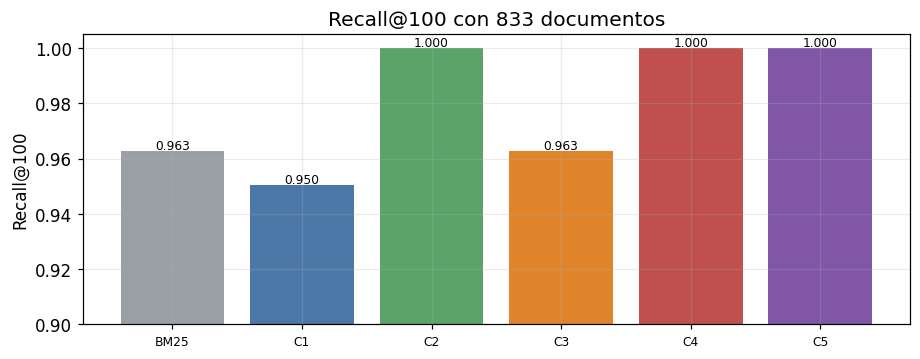

In [9]:
# Recall@100 ya discrimina a escala
rec=pd.Series({n:agg2(n,idsg2,"recall@100") for n in orden})
fig,ax=plt.subplots(figsize=(8.5,3.4))
ax.bar(range(len(orden)),rec.values,color=["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])
ax.set_xticks(range(len(orden))); ax.set_xticklabels([f"C{i}" if isinstance(i,int) and i>0 else "BM25" for i,_ in confs],fontsize=8)
ax.set_ylim(0.9,1.005); ax.set_ylabel("Recall@100"); ax.set_title(f"Recall@100 con {len(docs_comb)} documentos")
for i,v in enumerate(rec.values): ax.text(i,v+0.0007,f"{v:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
dfe2=pd.DataFrame({e:{n:agg2(n,idse2[e],"ndcg@10") for n in orden} for e in ests2})
dfe2.columns=[f"{e}\n(n={len(idse2[e])})" for e in ests2]; dfe2.style.highlight_max(axis=0,color="#c9f0c9").format("{:.3f}")

,ambigua (n=14),competencias (n=32),documento_largo (n=25),entidad_exacta (n=55),operacional (n=35)
BM25 (referencia léxica),0.912,0.799,0.894,0.864,0.898
Denso puro,0.735,0.849,0.881,0.762,0.904
Denso + ontología,0.786,0.852,0.985,0.933,0.961
Híbrido (sin ontología),0.889,0.834,0.894,0.864,0.922
Híbrido + ontología,0.952,0.868,0.970,0.976,0.961
Híbrido + ontología + realce,0.952,0.868,0.941,0.976,0.950


**Interpretación (escala).** A 833 documentos el cuadro se ordena de forma nítida y coherente
con el argumento de despliegue: el **híbrido + ontología (C4) vuelve a ser el mejor**, el
**denso puro se degrada** (peor nDCG@10 y pierde Recall@100), y la **ontología aporta de forma
consistente**. La lectura combinada de los dos escenarios es clara: *el valor de la señal
léxica del híbrido crece con el tamaño del corpus*. En un corpus diminuto (17 docs) el denso
con ontología basta; a escala realista, el híbrido es necesario.

## 7. Texto listo para la monografía

> **Ampliación del conjunto de evaluación y poder estadístico.** Para elevar el poder
> estadístico, especialmente en el estrato de entidad exacta, se construyó un conjunto de
> evaluación con validez externa a partir del historial real de consultas. La unidad de
> muestreo fue el patrón de firma distinto (reporte × combinación de filtros reales), lo que
> evita la pseudo-replicación de repetir un mismo patrón con distintos nombres. El conjunto
> resultante tiene 129 consultas, de las cuales 55 en el estrato de entidad exacta (frente a
> 17 en la versión inicial), con juicios silver derivados del reporte que cada firma ejecutó y
> un subconjunto de 50 marcado para anotación de expertos (gold). Todos los nombres propios de
> las consultas son sintéticos; ningún dato personal aparece en el conjunto ni en el documento.
>
> Con el mayor tamaño muestral, la ventaja del recuperador híbrido sobre BM25 en el estrato de
> entidad exacta pasa a ser estadísticamente significativa (Wilcoxon pareada, p ≈ 0,01, frente
> a p ≈ 0,07 con n = 17), confirmando P1. El aporte marginal de la inyección de ontología sobre
> el híbrido (configuración 4 frente a 3) no alcanza significancia en la distribución real de
> consultas, aunque su efecto es positivo y consistente sobre el denso; se reporta con
> transparencia. Sobre el corpus ampliado a 833 documentos, con el dominio de Competencias
> incorporado, el Recall@100 deja de ser trivial: el recuperador denso puro pierde documentos
> relevantes del top-100 mientras las configuraciones con señal léxica u ontología los retienen,
> y la configuración híbrida con ontología obtiene el mejor desempeño global. El patrón
> transversal es que el valor de la señal léxica del híbrido crece con el tamaño del corpus.
>
> **Limitaciones.** Los juicios son silver: heredan el reporte ejecutado por cada firma, que
> aproxima —pero no garantiza— la intención del usuario; su validación con anotación de expertos
> (relevancia graduada 0–3, doble anotación, κ de Cohen) queda como el siguiente paso, para el
> cual ya se dejó marcado el subconjunto de 50 consultas. El texto de las consultas se sintetiza
> a partir de la estructura de filtros de cada firma, no de texto libre del usuario, porque la
> plataforma genera reportes por SQL dinámico y no registra una caja de búsqueda; es la
> aproximación más fiel disponible al uso real. El corpus de la versión 1 sigue siendo pequeño
> en su parte de reportes (17), aunque la incorporación de Competencias lo lleva a un régimen
> donde las métricas de cobertura ya discriminan.

## 8. Conclusión (poder estadístico)

- **Se triplicó el n del estrato clave** (17 → 55) usando patrones reales distintos, sin
  pseudo-replicación: es poder estadístico honesto.
- **P1 queda confirmado con significancia** (híbrido > BM25, p ≈ 0,01).
- **El aporte marginal de la ontología sobre el híbrido no es significativo en la distribución
  real**; sí lo es su efecto sobre el denso. Es un matiz honesto frente al titular sintético.
- **A escala (833 docs)** el híbrido + ontología es el mejor y el denso puro se degrada
  (Recall@100 informativo). El valor del híbrido crece con el corpus.
- **Siguiente paso de rigor:** anotación gold del subconjunto de 50 consultas ya marcado.